# Stage 7 — Proper Evaluation of Treatment-Effect Models

## Why ordinary supervised-learning evaluation is not enough

For each user we observe only one factual outcome:

$$Y_i=T_iY_i(1)+(1-T_i)Y_i(0).$$

The individual treatment effect $Y_i(1)-Y_i(0)$ is never observed because its counterfactual component is missing. Therefore we cannot calculate individual CATE MSE or individual CATE accuracy from this dataset.

A proper evaluation asks observable questions:

1. Are the nuisance outcome models predictively reasonable on factual outcomes?
2. Are average predicted effects calibrated to the randomized experiment?
3. Does the score rank groups with different experimental effects?
4. Does the ranking improve a fixed-budget targeting policy?
5. Are apparent model differences larger than holdout uncertainty?

## Evaluation map

| Question | Metric | What it does not prove |
|---|---|---|
| Who visits? | ROC-AUC, PR-AUC | Incrementality |
| Is effect level calibrated? | Mean CATE vs ATE, BLP slope | Correct individual effects |
| Is ranking useful? | Uplift/Qini curve, AUUC, GATES | Profit at a specific cost |
| Is a policy useful? | Incremental visits at 10% or 30% | Transport to a new campaign |
| Is one model better? | Paired bootstrap difference | Full retraining uncertainty |

Metric definitions vary across uplift libraries. This notebook states its formulas explicitly rather than relying on a package label.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import econml
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn import __version__ as sklearn_version
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='X does not have valid feature names.*')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)
print('EconML       :', econml.__version__)

Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0
EconML       : 0.17.0


## 1. Reproduce the fixed sample and splits

The approximately one-million-row sample, 60/20/20 split, and 400,000-row model-training subset match Stages 4–6. The same training budget and untouched-within-notebook evaluation sets make the model comparison fair.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {**{c: 'float32' for c in FEATURES}, 'treatment': 'int8', 'visit': 'int8', 'conversion': 'int8'}
EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0
for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < SAMPLE_TARGET / EXPECTED_ROWS
    parts.append(chunk.loc[keep].copy())
df = pd.concat(parts, ignore_index=True)
print(f'Scanned {rows_scanned:,} rows in {time.perf_counter()-start:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows; memory {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB.')

Scanned 13,979,592 rows in 12.2 seconds.
Modeling sample: 999,453 rows; memory 48.6 MiB.


In [3]:
strata = df['treatment'].astype(str) + '_' + df['visit'].astype(str)
train_df, temp_df = train_test_split(df, test_size=.40, random_state=RANDOM_SEED, stratify=strata)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df['visit'].astype(str)
valid_df, test_df = train_test_split(temp_df, test_size=.50, random_state=RANDOM_SEED, stratify=temp_strata)
train_strata = train_df['treatment'].astype(str) + '_' + train_df['visit'].astype(str)
model_train, _ = train_test_split(train_df, train_size=400_000, random_state=RANDOM_SEED + 10, stratify=train_strata)

split_summary = pd.concat({
    name: frame.groupby('treatment')['visit'].agg(['size', 'sum', 'mean'])
    for name, frame in [('training', model_train), ('validation', valid_df), ('test', test_df)]
}, names=['split', 'treatment'])
display(split_summary)
assert model_train.index.intersection(valid_df.index).empty
assert model_train.index.intersection(test_df.index).empty
assert valid_df.index.intersection(test_df.index).empty
assert not set(['treatment', 'visit', 'conversion', 'exposure']).intersection(FEATURES)
print('Split and leakage checks passed.')

size    sum     mean
split      treatment                        
training   0           59831   2219 0.037088
           1          340169  16529 0.048591
validation 0           29899   1109 0.037092
           1          169992   8260 0.048591
test       0           29900   1109 0.037090
           1          169991   8260 0.048591

Split and leakage checks passed.


## 2. Fit three benchmark strategies

- **Response model:** predicts visit probability without treatment-effect modeling.
- **T-Learner:** fits separate treated and control response surfaces and subtracts them.
- **Causal Forest:** directly targets conditional effect heterogeneity after cross-fitted residualization.

All models use the same training rows. LightGBM early stopping uses validation only. Seeds and forest settings match Stage 4.

In [4]:
def make_lgbm(seed, n_estimators=600):
    return lgb.LGBMClassifier(
        objective='binary', n_estimators=n_estimators, learning_rate=.05,
        num_leaves=31, min_child_samples=200, colsample_bytree=.9,
        reg_lambda=1.0, random_state=seed, n_jobs=-1, verbosity=-1,
    )

treated_train = model_train['treatment'].eq(1)
control_train = model_train['treatment'].eq(0)
treated_valid = valid_df['treatment'].eq(1)
control_valid = valid_df['treatment'].eq(0)
model_treated = make_lgbm(RANDOM_SEED + 31)
model_control = make_lgbm(RANDOM_SEED + 32)
response_model = make_lgbm(RANDOM_SEED + 33)
fit_specs = [
    ('Treated outcome', model_treated, treated_train, treated_valid),
    ('Control outcome', model_control, control_train, control_valid),
    ('Pooled response', response_model, pd.Series(True, index=model_train.index), pd.Series(True, index=valid_df.index)),
]
fit_rows = []
for name, model, train_mask, valid_mask in fit_specs:
    start = time.perf_counter()
    model.fit(
        model_train.loc[train_mask, FEATURES], model_train.loc[train_mask, 'visit'],
        eval_set=[(valid_df.loc[valid_mask, FEATURES], valid_df.loc[valid_mask, 'visit'])],
        eval_metric='binary_logloss', callbacks=[lgb.early_stopping(40, verbose=False)],
    )
    fit_rows.append({'model': name, 'train_rows': int(train_mask.sum()), 'best_iteration': model.best_iteration_, 'fit_seconds': time.perf_counter()-start})

X_train = model_train[FEATURES].to_numpy(dtype=np.float32)
X_valid = valid_df[FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)
causal_forest = CausalForestDML(
    model_y=make_lgbm(RANDOM_SEED + 20, n_estimators=180),
    model_t=DummyClassifier(strategy='prior'),
    discrete_outcome=True, discrete_treatment=True, categories=[0, 1], cv=2,
    n_estimators=200, criterion='mse', max_depth=15,
    min_samples_leaf=200, max_samples=.45, honest=True,
    inference=True, subforest_size=4, n_jobs=-1,
    random_state=RANDOM_SEED + 20,
)
start = time.perf_counter()
causal_forest.fit(
    model_train['visit'].to_numpy(dtype=np.int8),
    model_train['treatment'].to_numpy(dtype=np.int8),
    X=X_train, inference='auto',
)
fit_rows.append({'model': 'Causal Forest', 'train_rows': len(model_train), 'best_iteration': 200, 'fit_seconds': time.perf_counter()-start})
display(pd.DataFrame(fit_rows).set_index('model'))

,train_rows,best_iteration,fit_seconds
model,,,
Treated outcome,340169,126,1.607028
Control outcome,59831,83,0.645807
Pooled response,400000,140,1.878822
Causal Forest,400000,200,51.976433


In [5]:
def make_scores(frame, X_numpy):
    p1 = model_treated.predict_proba(frame[FEATURES])[:, 1]
    p0 = model_control.predict_proba(frame[FEATURES])[:, 1]
    return {
        'Causal Forest': np.asarray(causal_forest.effect(X_numpy)).reshape(-1),
        'T-Learner': p1 - p0,
        'Response score': response_model.predict_proba(frame[FEATURES])[:, 1],
    }, p1, p0

scores_valid, valid_p1, valid_p0 = make_scores(valid_df, X_valid)
scores_test, test_p1, test_p0 = make_scores(test_df, X_test)
print('Generated validation and test scores for all three strategies.')

Generated validation and test scores for all three strategies.


## 3. Factual prediction metrics are diagnostics, not uplift metrics

The treated model can be evaluated on treated users and the control model on control users because those factual outcomes are observed. The pooled response model can be evaluated on everyone.

Good AUC or log loss is useful for nuisance quality, but it does not validate the difference between counterfactual response surfaces or the targeting policy.

In [6]:
def predictive_metrics(y, probability):
    return {
        'rows': len(y), 'event_rate': np.mean(y),
        'ROC_AUC': roc_auc_score(y, probability),
        'PR_AUC': average_precision_score(y, probability),
        'log_loss': log_loss(y, probability),
        'brier_score': brier_score_loss(y, probability),
    }

t_test = test_df['treatment'].to_numpy(dtype=np.int8)
y_test = test_df['visit'].to_numpy(dtype=np.int8)
response_test = scores_test['Response score']
factual_quality = pd.DataFrame({
    'Treated model on treated users': predictive_metrics(y_test[t_test == 1], test_p1[t_test == 1]),
    'Control model on control users': predictive_metrics(y_test[t_test == 0], test_p0[t_test == 0]),
    'Pooled response on all users': predictive_metrics(y_test, response_test),
}).T
display(factual_quality)

,rows,event_rate,ROC_AUC,PR_AUC,log_loss,brier_score
Treated model on treated users,"169,991.000000",0.048591,0.945157,0.519595,0.106132,0.030661
Control model on control users,"29,900.000000",0.037090,0.941917,0.448563,0.091059,0.025637
Pooled response on all users,"199,891.000000",0.046871,0.945108,0.508158,0.103978,0.029991


## 4. Observable causal ranking signal

Randomized treatment probability $p$ creates the inverse-propensity transformed outcome

$$Z_i=\frac{T_iY_i}{p}-\frac{(1-T_i)Y_i}{1-p},\qquad E[Z_i\mid X_i]=\tau(X_i).$$

For the top fraction $q$ under a score, the cumulative gain is

$$G(q)=\frac{1}{n}\sum_i 1\{rank_i\le q\}Z_i.$$

The random-ranking reference is $q\times ATE$. We define:

- **AUUC:** area under $G(q)$ from zero to one.
- **Qini-style coefficient:** AUUC minus the area under the random line, which is $ATE/2$.

Higher is better. Zero Qini means no improvement over random ordering; negative Qini means harmful ordering. These are population-average ranking metrics, not individual effect errors.

In [7]:
PROPENSITY = model_train['treatment'].mean()
FRACTIONS = np.linspace(.01, 1.0, 100)

def transformed_outcome(frame):
    t = frame['treatment'].to_numpy()
    y = frame['visit'].to_numpy()
    return t * y / PROPENSITY - (1 - t) * y / (1 - PROPENSITY)

def rank_fraction(score):
    order = np.argsort(-np.asarray(score), kind='stable')
    ranks = np.empty(len(order), dtype=float)
    ranks[order] = (np.arange(len(order)) + .5) / len(order)
    return ranks

def ipw_gain_curve(signal, score, fractions=FRACTIONS):
    order = np.argsort(-np.asarray(score), kind='stable')
    cumulative_gain = np.cumsum(signal[order]) / len(signal)
    indexes = np.maximum(1, np.ceil(fractions * len(signal)).astype(int)) - 1
    return cumulative_gain[indexes]

def top_mask(score, fraction):
    return rank_fraction(score) <= fraction

def hajek_policy_value(frame, score, fraction):
    mask = top_mask(score, fraction)
    t = frame['treatment'].to_numpy()[mask]
    y = frame['visit'].to_numpy()[mask]
    return fraction * (y[t == 1].mean() - y[t == 0].mean())

def ranking_metrics(frame, score):
    signal = transformed_outcome(frame)
    curve = ipw_gain_curve(signal, score)
    q_grid = np.r_[0, FRACTIONS]
    auuc = np.trapezoid(np.r_[0, curve], q_grid)
    ate_ipw = signal.mean()
    qini = auuc - ate_ipw / 2
    return {
        'ATE_IPW': ate_ipw,
        'AUUC_x1000': 1000 * auuc,
        'Qini_above_random_x1000': 1000 * qini,
        'IPW_value_at_10pct_per1k': 1000 * curve[9],
        'IPW_value_at_30pct_per1k': 1000 * curve[29],
        'Hajek_value_at_10pct_per1k': 1000 * hajek_policy_value(frame, score, .10),
        'Hajek_value_at_30pct_per1k': 1000 * hajek_policy_value(frame, score, .30),
    }

metric_rows = []
curve_store = {}
for split_name, frame, score_map in [('validation', valid_df, scores_valid), ('test', test_df, scores_test)]:
    signal = transformed_outcome(frame)
    for model_name, score in score_map.items():
        metric_rows.append({'split': split_name, 'model': model_name, **ranking_metrics(frame, score)})
        curve_store[(split_name, model_name)] = ipw_gain_curve(signal, score)
ranking_table = pd.DataFrame(metric_rows).set_index(['split', 'model'])
ranking_table['IPW_minus_Hajek_at_10pct_per1k'] = ranking_table['IPW_value_at_10pct_per1k'] - ranking_table['Hajek_value_at_10pct_per1k']
ranking_table['IPW_minus_Hajek_at_30pct_per1k'] = ranking_table['IPW_value_at_30pct_per1k'] - ranking_table['Hajek_value_at_30pct_per1k']
display(ranking_table)

validation_choice_qini = ranking_table.loc['validation', 'Qini_above_random_x1000'].idxmax()
validation_choice_30 = ranking_table.loc['validation', 'Hajek_value_at_30pct_per1k'].idxmax()
print('Validation choice by Qini:', validation_choice_qini)
print('Validation choice at 30% budget:', validation_choice_30)

ATE_IPW  AUUC_x1000  Qini_above_random_x1000  \
split      model                                                          
validation Causal Forest  0.011499    9.942278                 4.192638   
           T-Learner      0.011499    9.303572                 3.553932   
           Response score 0.011499   10.621369                 4.871729   
test       Causal Forest  0.011499   10.736956                 4.987316   
           T-Learner      0.011499   10.267391                 4.517751   
           Response score 0.011499   10.644817                 4.895177   

                           IPW_value_at_10pct_per1k  IPW_value_at_30pct_per1k  \
split      model                                                                
validation Causal Forest                   8.564459                  9.966635   
           T-Learner                       8.264301                  9.576873   
           Response score                  9.048090                 11.099548   
test       Causal Forest                  10.536759                 11.544134   
           T-Learner                       9.107512                 10.710183   
           Response score                  8.918340                 10.934834   

                           Hajek_value_at_10pct_per1k  \
split      model                                        
validation Causal Forest                     6.164630   
           T-Learner                         6.356901   
           Response score                    6.221918   
test       Causal Forest                     7.640042   
           T-Learner                         7.203911   
           Response score                    6.432127   

                           Hajek_value_at_30pct_per1k  \
split      model                                        
validation Causal Forest                     9.045585   
           T-Learner                         8.714423   
           Response score                    9.721635   
test       Causal Forest                    10.063015   
           T-Learner                         9.924702   
           Response score                   10.007912   

                           IPW_minus_Hajek_at_10pct_per1k  \
split      model                                            
validation Causal Forest                         2.399829   
           T-Learner                             1.907400   
           Response score                        2.826173   
test       Causal Forest                         2.896717   
           T-Learner                             1.903601   
           Response score                        2.486213   

                           IPW_minus_Hajek_at_30pct_per1k  
split      model                                           
validation Causal Forest                         0.921049  
           T-Learner                             0.862449  
           Response score                        1.377913  
test       Causal Forest                         1.481119  
           T-Learner                             0.785481  
           Response score                        0.926923

Validation choice by Qini: Response score
Validation choice at 30% budget: Response score


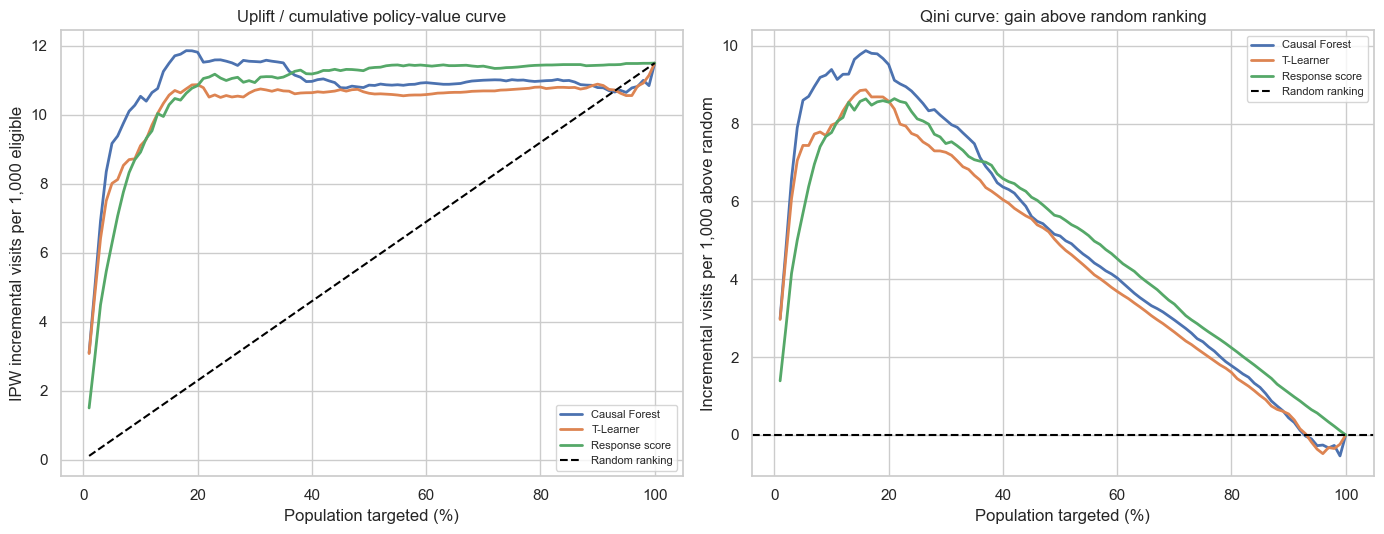

In [8]:
test_signal = transformed_outcome(test_df)
test_ate_ipw = test_signal.mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for model_name in scores_test:
    curve = curve_store[('test', model_name)]
    axes[0].plot(100 * FRACTIONS, 1000 * curve, linewidth=2, label=model_name)
    axes[1].plot(100 * FRACTIONS, 1000 * (curve - FRACTIONS * test_ate_ipw), linewidth=2, label=model_name)
axes[0].plot(100 * FRACTIONS, 1000 * FRACTIONS * test_ate_ipw, '--', color='black', label='Random ranking')
axes[1].axhline(0, linestyle='--', color='black', label='Random ranking')
axes[0].set(title='Uplift / cumulative policy-value curve', xlabel='Population targeted (%)', ylabel='IPW incremental visits per 1,000 eligible')
axes[1].set(title='Qini curve: gain above random ranking', xlabel='Population targeted (%)', ylabel='Incremental visits per 1,000 above random')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Horvitz–Thompson versus Hájek policy value

The IPW curve is a Horvitz–Thompson-style estimator using the randomized propensity. The fixed-budget table also reports the stabilized Hájek estimate used in Stage 6: selected treated mean minus selected control mean, multiplied by budget. Both target the same policy value and should be close in a large randomized sample; finite-sample arm imbalance can make them differ slightly.

## 5. GATES: group-average treatment effects by score decile

Users are sorted into ten equal-sized score groups. Within each group, observed uplift is estimated directly from randomized treated and control users. This evaluates group ranking without pretending that individual treatment effects are observed.

,model,decile,users,mean_score,observed_uplift,ci_95_low,ci_95_high
0,Causal Forest,1,19990,-0.004314,0.007983,-0.000852,0.016818
9,Causal Forest,10,19989,0.051010,0.076400,0.060117,0.092684
20,Response score,1,19990,0.000644,0.000647,0.000265,0.001029
29,Response score,10,19989,0.364883,0.064321,0.045706,0.082936
10,T-Learner,1,19990,-0.020330,0.007196,-0.004997,0.019389
19,T-Learner,10,19989,0.080859,0.072039,0.055828,0.088250


,top_decile_uplift,bottom_decile_uplift,top_minus_bottom,decile_rank_spearman
model,,,,
Causal Forest,0.076400,0.007983,0.068417,0.163636
Response score,0.064321,0.000647,0.063674,0.854545
T-Learner,0.072039,0.007196,0.064843,0.006061


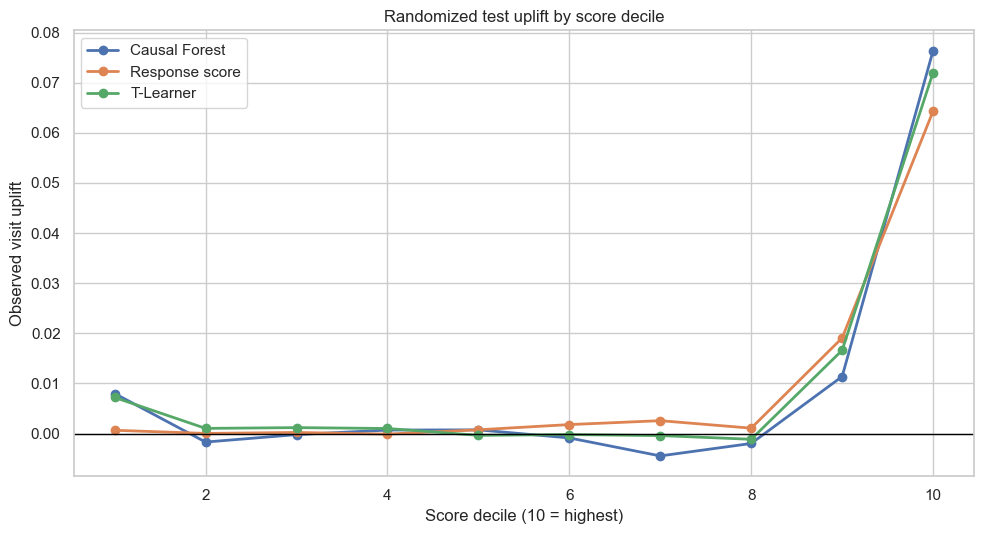

In [9]:
def effect_and_se(y, t):
    yt, yc = y[t == 1], y[t == 0]
    pt, pc = yt.mean(), yc.mean()
    effect = pt - pc
    se = np.sqrt(pt * (1 - pt) / len(yt) + pc * (1 - pc) / len(yc))
    return effect, se

def gates_table(frame, score, model_name):
    labels = pd.qcut(pd.Series(score).rank(method='first'), 10, labels=range(1, 11)).astype(int).to_numpy()
    y = frame['visit'].to_numpy()
    t = frame['treatment'].to_numpy()
    rows = []
    for decile in range(1, 11):
        mask = labels == decile
        effect, se = effect_and_se(y[mask], t[mask])
        rows.append({'model': model_name, 'decile': decile, 'users': int(mask.sum()),
                     'mean_score': np.mean(np.asarray(score)[mask]), 'observed_uplift': effect,
                     'ci_95_low': effect - 1.96 * se, 'ci_95_high': effect + 1.96 * se})
    return pd.DataFrame(rows)

gates = pd.concat([gates_table(test_df, score, name) for name, score in scores_test.items()], ignore_index=True)
display(gates.loc[gates['decile'].isin([1, 10])].sort_values(['model', 'decile']))

gates_summary_rows = []
for model_name, part in gates.groupby('model'):
    top = part.loc[part['decile'].eq(10)].iloc[0]
    bottom = part.loc[part['decile'].eq(1)].iloc[0]
    gates_summary_rows.append({
        'model': model_name,
        'top_decile_uplift': top['observed_uplift'],
        'bottom_decile_uplift': bottom['observed_uplift'],
        'top_minus_bottom': top['observed_uplift'] - bottom['observed_uplift'],
        'decile_rank_spearman': stats.spearmanr(part['decile'], part['observed_uplift']).statistic,
    })
gates_summary = pd.DataFrame(gates_summary_rows).set_index('model')
display(gates_summary)

fig, ax = plt.subplots(figsize=(10, 5.5))
for model_name, part in gates.groupby('model'):
    ax.plot(part['decile'], part['observed_uplift'], marker='o', linewidth=2, label=model_name)
ax.axhline(0, color='black', linewidth=1)
ax.set(title='Randomized test uplift by score decile', xlabel='Score decile (10 = highest)', ylabel='Observed visit uplift')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Effect-level calibration for CATE estimators

For Causal Forest and T-Learner, we regress the transformed outcome on the centered predicted CATE with HC3 robust standard errors.

- Intercept: average experimental effect.
- Positive slope: larger predicted effects correspond to larger realized group effects.
- Slope one: ideal linear scale calibration.

The response score is excluded because it is a visit probability, not an effect measured in CATE units.

In [10]:
def hc3_blp(signal, score):
    centered = np.asarray(score) - np.mean(score)
    design = np.column_stack([np.ones(len(centered)), centered])
    xtx_inv = np.linalg.inv(design.T @ design)
    coef = xtx_inv @ design.T @ signal
    residual = signal - design @ coef
    leverage = np.einsum('ij,jk,ik->i', design, xtx_inv, design)
    scaled_sq = (residual / (1 - leverage)) ** 2
    covariance = xtx_inv @ (design.T @ (design * scaled_sq[:, None])) @ xtx_inv
    se = np.sqrt(np.diag(covariance))
    return {
        'mean_predicted_CATE': np.mean(score),
        'ATE_intercept': coef[0],
        'slope': coef[1],
        'slope_se': se[1],
        'slope_ci_95_low': coef[1] - 1.96 * se[1],
        'slope_ci_95_high': coef[1] + 1.96 * se[1],
        'slope_p_value': 2 * stats.norm.sf(abs(coef[1] / se[1])),
    }

calibration_table = pd.DataFrame({
    model_name: hc3_blp(test_signal, scores_test[model_name])
    for model_name in ['Causal Forest', 'T-Learner']
}).T
display(calibration_table)

,mean_predicted_CATE,ATE_intercept,slope,slope_se,slope_ci_95_low,slope_ci_95_high,slope_p_value
Causal Forest,0.006740,0.011499,2.183456,0.149806,1.889837,2.477074,0.000000
T-Learner,0.007474,0.011499,1.082040,0.089392,0.906831,1.257249,0.000000


## 7. Paired bootstrap for metric and model uncertainty

All models are evaluated on the same resampled users, so differences are paired. We bootstrap:

- Qini-style area above random using fixed rank weights and the IPW signal.
- Stabilized Hájek policy value at the 30% budget.

Intervals are conditional on the fitted models and fixed score rankings. Full pipeline uncertainty would repeat model training inside each resample or across independent experiments.

In [11]:
N_BOOTSTRAP = 300
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 100)
n_test = len(test_df)
rank_map = {name: rank_fraction(score) for name, score in scores_test.items()}
mask30_map = {name: top_mask(score, .30) for name, score in scores_test.items()}
bootstrap_store = {
    (name, metric): np.empty(N_BOOTSTRAP)
    for name in scores_test for metric in ['Qini_x1000', 'Hajek30_per1k']
}

for b in range(N_BOOTSTRAP):
    idx = bootstrap_rng.integers(0, n_test, size=n_test)
    sampled_signal = test_signal[idx]
    sampled_t = t_test[idx]
    sampled_y = y_test[idx]
    for model_name in scores_test:
        weights = .5 - rank_map[model_name][idx]
        bootstrap_store[(model_name, 'Qini_x1000')][b] = 1000 * np.mean(weights * sampled_signal)
        selected = mask30_map[model_name][idx]
        effect = sampled_y[selected & (sampled_t == 1)].mean() - sampled_y[selected & (sampled_t == 0)].mean()
        bootstrap_store[(model_name, 'Hajek30_per1k')][b] = 1000 * .30 * effect

bootstrap_rows = []
for model_name in scores_test:
    for metric in ['Qini_x1000', 'Hajek30_per1k']:
        draws = bootstrap_store[(model_name, metric)]
        point = (
            ranking_table.loc[('test', model_name), 'Qini_above_random_x1000']
            if metric == 'Qini_x1000'
            else ranking_table.loc[('test', model_name), 'Hajek_value_at_30pct_per1k']
        )
        bootstrap_rows.append({'model': model_name, 'metric': metric, 'point_estimate': point,
                               'bootstrap_mean': draws.mean(), 'ci_95_low': np.quantile(draws, .025),
                               'ci_95_high': np.quantile(draws, .975), 'probability_positive': np.mean(draws > 0)})
bootstrap_summary = pd.DataFrame(bootstrap_rows).set_index(['model', 'metric'])
display(bootstrap_summary)

pair_rows = []
for competitor in ['T-Learner', 'Response score']:
    for metric in ['Qini_x1000', 'Hajek30_per1k']:
        diff = bootstrap_store[('Causal Forest', metric)] - bootstrap_store[(competitor, metric)]
        cf_point = bootstrap_summary.loc[('Causal Forest', metric), 'point_estimate']
        competitor_point = bootstrap_summary.loc[(competitor, metric), 'point_estimate']
        pair_rows.append({'comparison': f'Causal Forest minus {competitor}', 'metric': metric,
                          'point_difference': cf_point - competitor_point,
                          'ci_95_low': np.quantile(diff, .025), 'ci_95_high': np.quantile(diff, .975),
                          'probability_CF_better': np.mean(diff > 0)})
paired_comparisons = pd.DataFrame(pair_rows).set_index(['comparison', 'metric'])
display(paired_comparisons)

point_estimate  bootstrap_mean  ci_95_low  \
model          metric                                                     
Causal Forest  Qini_x1000           4.987316        4.991307   3.827017   
               Hajek30_per1k       10.063015       10.070582   7.780189   
T-Learner      Qini_x1000           4.517751        4.541719   3.596733   
               Hajek30_per1k        9.924702        9.967747   8.132777   
Response score Qini_x1000           4.895177        4.914358   3.712454   
               Hajek30_per1k       10.007912       10.057094   7.601012   

                              ci_95_high  probability_positive  
model          metric                                           
Causal Forest  Qini_x1000       5.952539              1.000000  
               Hajek30_per1k   12.025108              1.000000  
T-Learner      Qini_x1000       5.484665              1.000000  
               Hajek30_per1k   11.682315              1.000000  
Response score Qini_x1000       5.932244              1.000000  
               Hajek30_per1k   12.376559              1.000000

point_difference  ci_95_low  \
comparison                         metric                                       
Causal Forest minus T-Learner      Qini_x1000             0.469565  -0.491954   
                                   Hajek30_per1k          0.138312  -1.059744   
Causal Forest minus Response score Qini_x1000             0.092139  -0.784248   
                                   Hajek30_per1k          0.055103  -1.042962   

                                                  ci_95_high  \
comparison                         metric                      
Causal Forest minus T-Learner      Qini_x1000       1.388588   
                                   Hajek30_per1k    1.222356   
Causal Forest minus Response score Qini_x1000       0.961075   
                                   Hajek30_per1k    1.171502   

                                                  probability_CF_better  
comparison                         metric                                
Causal Forest minus T-Learner      Qini_x1000                  0.810000  
                                   Hajek30_per1k               0.570000  
Causal Forest minus Response score Qini_x1000                  0.576667  
                                   Hajek30_per1k               0.506667

## 8. Sanity checks: random and deliberately reversed rankings

A trustworthy evaluation implementation should give approximately zero Qini to an independent random score and poor or negative Qini when a useful score is reversed. These are metric-code checks, not candidate production models.

,Qini_above_random_x1000,Qini_ci_95_low,Qini_ci_95_high,Hajek_value_at_10pct_per1k,Hajek_value_at_30pct_per1k
Causal Forest,4.987316,4.002265,5.972367,7.640042,10.063015
Random score,0.319632,-0.373646,1.012910,1.688165,4.051344
Reversed Causal Forest,-4.987415,-5.972466,-4.002364,0.798703,0.611884


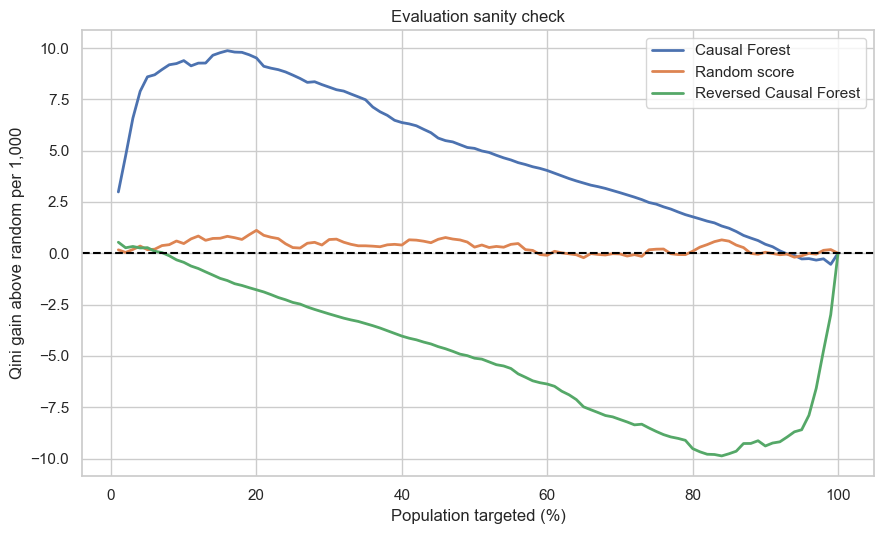

In [12]:
sanity_rng = np.random.default_rng(RANDOM_SEED + 999)
sanity_scores = {
    'Causal Forest': scores_test['Causal Forest'],
    'Random score': sanity_rng.normal(size=len(test_df)),
    'Reversed Causal Forest': -scores_test['Causal Forest'],
}
sanity_table = pd.DataFrame({name: ranking_metrics(test_df, score) for name, score in sanity_scores.items()}).T
for name, score in sanity_scores.items():
    contribution = 1000 * (.5 - rank_fraction(score)) * test_signal
    qini_se = contribution.std(ddof=1) / np.sqrt(len(contribution))
    sanity_table.loc[name, 'Qini_ci_95_low'] = sanity_table.loc[name, 'Qini_above_random_x1000'] - 1.96 * qini_se
    sanity_table.loc[name, 'Qini_ci_95_high'] = sanity_table.loc[name, 'Qini_above_random_x1000'] + 1.96 * qini_se
display(sanity_table[['Qini_above_random_x1000', 'Qini_ci_95_low', 'Qini_ci_95_high', 'Hajek_value_at_10pct_per1k', 'Hajek_value_at_30pct_per1k']])

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, score in sanity_scores.items():
    curve = ipw_gain_curve(test_signal, score)
    ax.plot(100 * FRACTIONS, 1000 * (curve - FRACTIONS * test_ate_ipw), linewidth=2, label=name)
ax.axhline(0, linestyle='--', color='black')
ax.set(title='Evaluation sanity check', xlabel='Population targeted (%)', ylabel='Qini gain above random per 1,000')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Test-set governance audit

Within this notebook, test outcomes do not affect fitting, score construction, or validation choices. Across the project, however, the same test results have already been inspected in earlier stages. It is therefore no longer a truly untouched final holdout for a publication-grade claim.

A production-quality next step would freeze the pipeline before accessing either:

- a fresh locked slice never used during development, or
- a new prospective randomized policy experiment.

This distinction prevents a repeatedly inspected evaluation split from being described as an untouched final test set.

## 10. Automatically generated evaluation summary

The narrative below is populated from the executed results.

In [13]:
test_ate_hajek, test_ate_se = effect_and_se(y_test, t_test)
cf_test = ranking_table.loc[('test', 'Causal Forest')]
tl_test = ranking_table.loc[('test', 'T-Learner')]
rs_test = ranking_table.loc[('test', 'Response score')]
cf_gate = gates_summary.loc['Causal Forest']
tl_gate = gates_summary.loc['T-Learner']
rs_gate = gates_summary.loc['Response score']
cf_cal = calibration_table.loc['Causal Forest']
tl_cal = calibration_table.loc['T-Learner']
cf_vs_t_qini = paired_comparisons.loc[('Causal Forest minus T-Learner', 'Qini_x1000')]
cf_vs_r_qini = paired_comparisons.loc[('Causal Forest minus Response score', 'Qini_x1000')]
cf_vs_t_30 = paired_comparisons.loc[('Causal Forest minus T-Learner', 'Hajek30_per1k')]
cf_vs_r_30 = paired_comparisons.loc[('Causal Forest minus Response score', 'Hajek30_per1k')]

display(Markdown(f'''### Main findings

- The randomized test ATE is **{test_ate_hajek:.3%}** (95% normal CI **{test_ate_hajek-1.96*test_ate_se:.3%} to {test_ate_hajek+1.96*test_ate_se:.3%}**). This design-based estimate is preferred for the overall average effect.
- Validation chooses **{validation_choice_qini}** by Qini and **{validation_choice_30}** at the 30% budget. Because both pre-test criteria choose Response, the disciplined selection is Response; the test set estimates its final performance and should not be reused to switch to the marginal test leader.
- Test Qini above random (scaled by 1,000): Causal Forest **{cf_test.Qini_above_random_x1000:.2f}**, T-Learner **{tl_test.Qini_above_random_x1000:.2f}**, Response **{rs_test.Qini_above_random_x1000:.2f}**.
- Stabilized 30% policy value per 1,000 eligible users: Causal Forest **{cf_test.Hajek_value_at_30pct_per1k:.2f}**, T-Learner **{tl_test.Hajek_value_at_30pct_per1k:.2f}**, Response **{rs_test.Hajek_value_at_30pct_per1k:.2f}**.
- At 30%, the Forest IPW estimate is **{cf_test.IPW_value_at_30pct_per1k:.2f}** versus Hájek **{cf_test.Hajek_value_at_30pct_per1k:.2f}** per 1,000. This material finite-sample gap illustrates the variance sensitivity of raw inverse-propensity gains; use the stabilized Hájek estimate for the fixed-budget business result and state the estimator used.
- Causal Forest top-decile observed uplift is **{cf_gate.top_decile_uplift:.3%}**, versus **{cf_gate.bottom_decile_uplift:.3%}** in its bottom decile. Decile-rank Spearman correlations are Forest **{cf_gate.decile_rank_spearman:.3f}**, T-Learner **{tl_gate.decile_rank_spearman:.3f}**, and Response **{rs_gate.decile_rank_spearman:.3f}**. Response provides the smoothest group ordering here, while Forest isolates the strongest top group.
- Causal Forest mean predicted CATE is **{cf_cal.mean_predicted_CATE:.3%}** and BLP slope is **{cf_cal.slope:.2f}** (95% CI **{cf_cal.slope_ci_95_low:.2f} to {cf_cal.slope_ci_95_high:.2f}**). T-Learner mean CATE is **{tl_cal.mean_predicted_CATE:.3%}** with slope **{tl_cal.slope:.2f}** (95% CI **{tl_cal.slope_ci_95_low:.2f} to {tl_cal.slope_ci_95_high:.2f}**). Mean calibration and heterogeneity-scale calibration are separate properties.
- Qini difference, Causal Forest minus T-Learner: **{cf_vs_t_qini.point_difference:+.2f}** (95% paired bootstrap CI **{cf_vs_t_qini.ci_95_low:+.2f} to {cf_vs_t_qini.ci_95_high:+.2f}**). Versus Response: **{cf_vs_r_qini.point_difference:+.2f}** (95% CI **{cf_vs_r_qini.ci_95_low:+.2f} to {cf_vs_r_qini.ci_95_high:+.2f}**).
- At 30%, Causal Forest minus T-Learner is **{cf_vs_t_30.point_difference:+.2f} visits per 1,000** (95% CI **{cf_vs_t_30.ci_95_low:+.2f} to {cf_vs_t_30.ci_95_high:+.2f}**); minus Response is **{cf_vs_r_30.point_difference:+.2f}** (95% CI **{cf_vs_r_30.ci_95_low:+.2f} to {cf_vs_r_30.ci_95_high:+.2f}**).
- The random-score Qini is **{sanity_table.loc['Random score', 'Qini_above_random_x1000']:.2f}** (approximate 95% CI **{sanity_table.loc['Random score', 'Qini_ci_95_low']:.2f} to {sanity_table.loc['Random score', 'Qini_ci_95_high']:.2f}**), while reversing the forest gives **{sanity_table.loc['Reversed Causal Forest', 'Qini_above_random_x1000']:.2f}**. Random is compatible with zero and reversal flips direction, supporting the implementation check.

**Conclusion:** ranking quality depends on the chosen operating budget and metric. The pre-test rule selects Response, while test differences among learned models are inconclusive. Point-estimate leaderboards are insufficient; report calibration, curves, fixed-budget value, paired uncertainty, and validation-to-test stability together.
'''))

### Main findings

- The randomized test ATE is **1.150%** (95% normal CI **0.913% to 1.387%**). This design-based estimate is preferred for the overall average effect.
- Validation chooses **Response score** by Qini and **Response score** at the 30% budget. Because both pre-test criteria choose Response, the disciplined selection is Response; the test set estimates its final performance and should not be reused to switch to the marginal test leader.
- Test Qini above random (scaled by 1,000): Causal Forest **4.99**, T-Learner **4.52**, Response **4.90**.
- Stabilized 30% policy value per 1,000 eligible users: Causal Forest **10.06**, T-Learner **9.92**, Response **10.01**.
- At 30%, the Forest IPW estimate is **11.54** versus Hájek **10.06** per 1,000. This material finite-sample gap illustrates the variance sensitivity of raw inverse-propensity gains; use the stabilized Hájek estimate for the fixed-budget business result and state the estimator used.
- Causal Forest top-decile observed uplift is **7.640%**, versus **0.798%** in its bottom decile. Decile-rank Spearman correlations are Forest **0.164**, T-Learner **0.006**, and Response **0.855**. Response provides the smoothest group ordering here, while Forest isolates the strongest top group.
- Causal Forest mean predicted CATE is **0.674%** and BLP slope is **2.18** (95% CI **1.89 to 2.48**). T-Learner mean CATE is **0.747%** with slope **1.08** (95% CI **0.91 to 1.26**). Mean calibration and heterogeneity-scale calibration are separate properties.
- Qini difference, Causal Forest minus T-Learner: **+0.47** (95% paired bootstrap CI **-0.49 to +1.39**). Versus Response: **+0.09** (95% CI **-0.78 to +0.96**).
- At 30%, Causal Forest minus T-Learner is **+0.14 visits per 1,000** (95% CI **-1.06 to +1.22**); minus Response is **+0.06** (95% CI **-1.04 to +1.17**).
- The random-score Qini is **0.32** (approximate 95% CI **-0.37 to 1.01**), while reversing the forest gives **-4.99**. Random is compatible with zero and reversal flips direction, supporting the implementation check.

**Conclusion:** ranking quality depends on the chosen operating budget and metric. The pre-test rule selects Response, while test differences among learned models are inconclusive. Point-estimate leaderboards are insufficient; report calibration, curves, fixed-budget value, paired uncertainty, and validation-to-test stability together.


## 11. Evaluation notes

- Individual CATE MSE is unavailable because each user reveals either the treated or control potential outcome, never both.
- The uplift curve reports cumulative incremental outcomes under a ranking; the Qini curve subtracts the corresponding random-ranking gain. Exact definitions and scaling should always be stated.
- A response model can have good Qini when response likelihood and treatment responsiveness are correlated, but randomized policy evaluation—not the model label—determines its incremental value.
- IPW provides an additive transformed-outcome signal for ranking curves and paired inference. Stabilized Hájek estimates are often lower variance for fixed-budget business evaluation.
- Model selection metrics should match the operating decision and be fixed in advance. A 30% targeting constraint favors validation policy value over an integrated all-budget metric.
- A positive BLP slope supports effect ordering but does not reveal individual effects or guarantee transportability.
- Repeated inspection can indirectly influence development choices, so a new holdout or prospective experiment is required for a final production claim.

### Evaluation checklist

1. Pre-specify the primary outcome, budget, value function, and metric.
2. Train and tune without final-holdout outcomes.
3. Check overlap, randomization, delivery, and feature leakage.
4. Report calibration, GATES, uplift/Qini curves, and fixed-budget policy value.
5. Use paired uncertainty for model differences and include retraining sensitivity.
6. Lock the policy and validate it in a prospective randomized policy experiment.